## ERA5 Autoencoder ML tutorial - Evaluating ERA5 autoencoder
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-07-13
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

This notebook looks at how we can use a trained model that has gidded data as input and output to produce predictions, and evaluate the skills of those predictions. In this particular case, we're looking at an [*autoencoder*](https://www.geeksforgeeks.org/deep-learning/implementing-an-autoencoder-in-pytorch/) model, so the model is just predicting the input, but it still demonstrates the concepts that can be extended to useful model for forecasts, downscaling, temporal interpolation etc.


### Prerequisites 
- Have worked through the *Climate Zones* tutorial or similar on creating an ML pipeline
- Have set up the dscop pytorch environment


### Learning outcomes from completing the notebook
- Understand how to load a trained model
- Understand how to undo the normalisation data for traing to retrieve forecasts in the original units
- Understand how to evaluate gridded output for a regression type problem.

## Tutorial - Evaluating a gridded regression model
In this tutorial we will use a trained autoencoder model and demonstrate how to use it for making predictions (inference) and how to evaluate the skill/accuracy of the predictions.

Further Reading
* [PyTorch Docs](https://pytorch.org/)

### Environment 
This notebook uses the environment defined in this repository in environmentsddirectory:
 - Conda requirements YAML file [environments/requirements_pytorch.yaml](../../../environments/requirements_pytorch.yaml)
 - pip requirements file [environments/requirements_pytorch.txt](../../../environments/requirements_pytorch.txt)

Note that you will need to run the setup on the exact compute configuration to be used for training to ensure the right libraries are intalled. In particular if you are on a compute cluster with some GPU nodes, make sure you run the setup on a GPU node to ensure the GPU is deteced during environment installation so the GPU can be utilised for accelerating ML training and inference.

Platform Specific advice:
* **Met Office** - If you are running this notebook on Met Office IT, please follow the [guidance on using conda at the Met Office](https://wwwspice/~avd/sci/software_stack/conda_initial_how_to.html).
* **JASMIN** - On JASMIN, from the command line you should set up a conda environment. If you are using running a notebook, you will need to set up a venv instead as conda environments don't work with the notebook service.
* **Other** For other platforms please consult the relevant platform specific guidance on using conda on that platform where it exists, or [general conda documentation](https://www.anaconda.com/docs/getting-started/miniconda/install/overview) for getting started.

## Tutorial 
The principles of evaluating an ML model with gridded is the same as for other ML models (and indeed the same as for other predictive models that work with such data). How to evaluate weather and climate models is a well studied area and we can make use of existing tools and practices. In this tutorial we will use the scores



#### Import libraries
Key libraries for this tutorial include:
- Xarray for loading the input dataset
- scikit learn for preparing the data for training
- pytorch for creating and training the neural network
- matplotlib and cartopy for visualising the results
- scores for evaluating model performance

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pathlib
import os
import datetime
import json
import re
import copy
import sys

In [3]:
import numpy 
import xarray

In [4]:
import matplotlib
import matplotlib.pyplot
import cartopy.crs

In [5]:
import sklearn
import sklearn.preprocessing
import sklearn.tree


In [6]:
import mlflow

In [7]:
import torch

In [8]:
import scores

In [9]:
# era5_ae_src_path = pathlib.Path('.').absolute().parent / 'src'/ 'ai4c_hack'
# sys.path.append(str(era5_ae_src_path))


In [26]:
from  ERA5_autoencoder import Era5AutoEncoder, create_data_loaders

### Specify the experiment setup

Next we specify the experiment parameters through the config file anmd specifying other elements like file paths.

The tutorial config from the JSON file.

In [11]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25a/mmh_storage/ai4c_data/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer

In [12]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'weatherbench'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'weatherbench'
    return root_path

In [13]:
current_platform = tutorial_config['platform']

In [14]:
current_platform

'jasmin'

In [15]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench')

Define the key parameters for this experiment.

In [16]:
resolution_dict = {5.625: '5.625deg'}

In [17]:
mlready_dir = root_data_dir / 'mlready'

In [18]:
weatherbench_dir = mlready_dir / 'orig'
print(weatherbench_dir.is_dir())
weatherbench_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/mlready/orig')

In [19]:
wb_arco_path = mlready_dir / 'norm'
print(wb_arco_path.is_dir())
wb_arco_path

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/mlready/norm')

In [20]:
xarray.open_zarr(weatherbench_dir)

/gws/ssde/j25a/mmh_storage/user/shaddad/venv/ai4c_nb_gpu/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


<xarray.Dataset> Size: 66GB
Dimensions:              (time: 324337, level: 5, lat: 32, lon: 64)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1980-01-01 ... 2016-12-31
  * level                (level) int32 20B 1000 850 700 500 200
  * lat                  (lat) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * lon                  (lon) float64 512B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    geopotential         (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    specific_humidity    (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    temperature          (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    u_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    v_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

### Load data and models

In the training tutorials we defined a dataset and model classes. We will noe just load these in from a python module to avoid repeating the code, and then use these to load the data and model.

In [21]:
train_interval = (
    datetime.datetime(1980,1,1,0,0),
    datetime.datetime(2014,1,1,0,0),
)
val_interval = (
    datetime.datetime(2014,1,1,0,0),
    datetime.datetime(2016,1,1,0,0),
)

In [110]:
var_subset = ['temperature', 'geopotential']

data_pl = [200, 500, 700, 850,1000]  
pl_subset = [500, 850, ]  
pl_subset_indices = [data_pl.index(v1) for v1 in pl_subset]
num_channels = len(var_subset) * len(pl_subset)

In [62]:
batch_size=16

In [63]:
(wb_train_ds, wb_train_loader, wb_val_ds, wb_val_loader) = create_data_loaders(
    wb_arco_path, 
    var_subset,
    pl_subset,
    16,
    train_interval,
    val_interval,
)

num channels: 4
length train: 298057; length validation: 17521


In [64]:
wb_train_ds.num_channels

4

In [65]:
wb_val_loader.batch_size

16

### Loading the model
Here we will load in the pytorch model file that has been previously saved. UIf you have run the training successfully, you can change the path to point to the model that you saved.

In [66]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [67]:
model_dir = pathlib.Path('/gws/ssde/j25a/mmh_storage/user/shaddad/experiments/era5_autoencoder/latest/')
model_fname = 'era5_ae_model.pth'
model_path = model_dir / model_fname
print(model_path.is_file())
model_path

True


PosixPath('/gws/ssde/j25a/mmh_storage/user/shaddad/experiments/era5_autoencoder/latest/era5_ae_model.pth')

In [68]:
ae_model = torch.load(model_path, 
                      weights_only=False,
                      map_location=torch.device('cpu'),
                     )
ae_model

Era5AutoEncoder(
  (_encoder): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (_decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 4, kernel_size=(2, 2), stride=(2, 2))
  )
)

## Denormalising the data
The predictions coming out of the model will normalised, as was the training data. We want to see the values in the original units, so we need to reverse the normalisation. The code belows shows how we can check our denomralisation gives us the values we expect by comparing a denormalised array to values in the orignal data before normalisation was applied.

In [69]:
stats_path = mlready_dir / 'stats.json'

In [70]:
with open(stats_path,'r') as stats_file:
    stats_dict = json.load(stats_file)
stats_dict

{'temperature': {'mean': [281.00140380859375,
   274.55267333984375,
   267.38201904296875,
   252.93836975097656,
   218.0356903076172],
  'std': [17.117088317871094,
   15.580572128295898,
   14.770453453063965,
   13.066621780395508,
   7.193727493286133]},
 'specific_humidity': {'mean': [0.007025435566902161,
   0.004566648509353399,
   0.0024279849603772163,
   0.0008522787829861045,
   1.9398579752305523e-05],
  'std': [0.005913375411182642,
   0.004104434512555599,
   0.002542734844610095,
   0.0010768964421004057,
   2.262131602037698e-05]},
 'u_component_of_wind': {'mean': [-0.06702224165201187,
   1.3955833911895752,
   3.3002498149871826,
   6.556752681732178,
   14.211994171142578],
  'std': [6.1425700187683105,
   8.187788963317871,
   9.2008056640625,
   11.98122501373291,
   17.673219680786133]},
 'v_component_of_wind': {'mean': [0.2201852649450302,
   0.16798953711986542,
   0.0412067212164402,
   -0.02302303910255432,
   -0.0445253811776638],
  'std': [5.31966018676757

In [105]:
pl_subset


274.55267333984375

In [112]:
mean_vec = numpy.concat([numpy.array([stats_dict[var_name]['mean'][ix1] for ix1 in pl_subset_indices]) for var_name in var_subset])
std_vec = numpy.concat([numpy.array([stats_dict[var_name]['std'][ix1] for ix1 in pl_subset_indices]) for var_name in var_subset])

In [113]:
mean_vec

array([  274.55267334,   252.93836975, 13748.86816406, 54113.2265625 ])

In [114]:
std_vec

array([  15.58057213,   13.06662178, 1470.57727051, 3352.85620117])

In [72]:
wb_val_ds._ds_norm.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array('2014-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2014-01-01
Attributes:
    long_name:  time

In [73]:
sample_time = '2014-01-01 00:00'

In [74]:
sample_input = wb_val_ds._ds_norm.sel(time=sample_time)
sample_input

<xarray.Dataset> Size: 34kB
Dimensions:       (level: 2, lat: 32, lon: 64)
Coordinates:
  * level         (level) int32 8B 500 850
  * lat           (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon           (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    time          datetime64[ns] 8B 2014-01-01
Data variables:
    temperature   (level, lat, lon) float32 16kB dask.array<chunksize=(2, 32, 64), meta=np.ndarray>
    geopotential  (level, lat, lon) float32 16kB dask.array<chunksize=(2, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [75]:
sample_shape = dict(sample_input.dims)
sample_shape

{'level': 2, 'lat': 32, 'lon': 64}

In [76]:
sample_input_arr = numpy.stack([sample_input[v1] for v1 in sample_input.data_vars]).reshape([num_channels, sample_shape['lat'], sample_shape['lon']])

In [77]:
orig_ds = xarray.open_zarr(weatherbench_dir)
orig_ds

<xarray.Dataset> Size: 66GB
Dimensions:              (time: 324337, level: 5, lat: 32, lon: 64)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1980-01-01 ... 2016-12-31
  * level                (level) int32 20B 1000 850 700 500 200
  * lat                  (lat) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * lon                  (lon) float64 512B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    geopotential         (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    specific_humidity    (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    temperature          (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    u_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    v_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [154]:
sample_data_orig = orig_ds[var_subset].sel(time=sample_time, level=pl_subset)

In [155]:
sample_data_orig

<xarray.Dataset> Size: 34kB
Dimensions:       (level: 2, lat: 32, lon: 64)
Coordinates:
  * level         (level) int32 8B 500 850
  * lat           (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon           (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    time          datetime64[ns] 8B 2014-01-01
Data variables:
    temperature   (level, lat, lon) float32 16kB dask.array<chunksize=(2, 32, 64), meta=np.ndarray>
    geopotential  (level, lat, lon) float32 16kB dask.array<chunksize=(2, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [156]:
sample_orig_arr = numpy.stack([sample_data_orig[v1] for v1 in sample_data_orig.data_vars]).reshape([num_channels, sample_shape['lat'], sample_shape['lon']])

In [157]:
sample_orig_arr

array([[[  238.62056,   238.65988,   238.5789 , ...,   238.13696,
           238.3429 ,   238.50717],
        [  243.39168,   243.22276,   242.75307, ...,   243.17879,
           243.47498,   243.50043],
        [  240.56418,   238.60667,   238.2781 , ...,   242.96594,
           242.28337,   241.9733 ],
        ...,
        [  233.71523,   232.5236 ,   232.52591, ...,   235.89719,
           235.43903,   235.07346],
        [  231.66286,   231.41064,   231.26025, ...,   233.76613,
           233.2571 ,   232.29918],
        [  233.55557,   233.55095,   233.60185, ...,   233.58565,
           233.58565,   233.5764 ]],

       [[  254.84747,   254.8012 ,   254.78731, ...,   255.34958,
           255.12514,   254.94466],
        [  257.948  ,   257.7791 ,   257.5431 , ...,   258.4478 ,
           257.76752,   257.4066 ],
        [  258.61438,   258.45938,   258.24417, ...,   262.87875,
           261.4929 ,   258.31128],
        ...,
        [  259.54456,   260.55338,   260.93747, ...,  

In [158]:
sample_orig_arr.mean((1,2))

array([  252.18835,   273.83917, 54056.35   , 13819.696  ], dtype=float32)

In [159]:
sample_input_arr.mean((1,2))

array([  273.65836683,   252.71671275, 13681.52435439, 54274.71278614])

In [160]:
sample_denorm_arr = (sample_input_arr * std_vec.reshape(len(std_vec),1,1)) + mean_vec.reshape(len(mean_vec),1,1)

In [161]:
sample_denorm_arr

array([[[4.28624136e+03, 4.28697189e+03, 4.28546746e+03, ...,
         4.27725701e+03, 4.28108286e+03, 4.28413481e+03],
        [4.37488011e+03, 4.37174199e+03, 4.36301588e+03, ...,
         4.37092499e+03, 4.37642763e+03, 4.37690049e+03],
        [4.32235028e+03, 4.28598338e+03, 4.27987919e+03, ...,
         4.36697071e+03, 4.35428978e+03, 4.34852917e+03],
        ...,
        [4.19510910e+03, 4.17297095e+03, 4.17301375e+03, ...,
         4.23564600e+03, 4.22713421e+03, 4.22034256e+03],
        [4.15697982e+03, 4.15229415e+03, 4.14950016e+03, ...,
         4.19605481e+03, 4.18659789e+03, 4.16880152e+03],
        [4.19214304e+03, 4.19205715e+03, 4.19300283e+03, ...,
         4.19270178e+03, 4.19270178e+03, 4.19253001e+03]],

       [[3.38489644e+03, 3.38722894e+03, 3.38956144e+03, ...,
         3.37739925e+03, 3.37989844e+03, 3.38239745e+03],
        [3.40089036e+03, 3.40588854e+03, 3.41105322e+03, ...,
         3.38906156e+03, 3.39289349e+03, 3.39639205e+03],
        [3.37490026e+03, 

In [162]:
sample_denorm_arr.shape

(4, 32, 64)

In [163]:
numpy.histogram(sample_denorm_arr - sample_orig_arr)

(array([4976, 1168,    0,    0,    0,    0,    0,    4,  587, 1457]),
 array([2.99469658e+03, 1.96043228e+07, 3.92056509e+07, 5.88069790e+07,
        7.84083071e+07, 9.80096352e+07, 1.17610963e+08, 1.37212291e+08,
        1.56813620e+08, 1.76414948e+08, 1.96016276e+08]))

In [164]:
sample_denorm_arr.mean((1,2))

array([4.53830660e+03, 3.55509207e+03, 2.01334876e+07, 1.82029421e+08])

In [165]:
sample_orig_arr.mean((1,2,))

array([  252.18835,   273.83917, 54056.35   , 13819.696  ], dtype=float32)

### Make predictions and visualise
Now we are hoing to take the model we have loaded, and use it make some predictions, and then visualise them.

In [90]:
def create_da_skeleton(select_ds, var_list, pl_list):
    return [select_ds[v1][0,pix1] for v1 in var_list for pix1,p1 in enumerate(reversed(pl_list))]


In [91]:
def denormalise_tensor(tensor, std_vec, mean_vec, sample_da_list):
    current_arr = tensor.detach().numpy()
    denorm_arr = (current_arr * std_vec.reshape(len(std_vec),1,1)) + mean_vec.reshape(len(mean_vec),1,1)
    if sample_da_list is not None:
        merge_dict = {}
        for ix1 in range(len(sample_da_list)):
            new_da = copy.deepcopy(sample_da_list[ix1])
            if len(denorm_arr.shape) == 4:
                new_da.data = denorm_arr[0,ix1,:,:]
            elif  len(denorm_arr.shape) == 3:
                new_da.data = denorm_arr[ix1,:,:]
            else:
                raise RuntimeError('unexpected tensor shape')
            try:
                merge_dict[new_da.name] += [new_da]
            except KeyError:
                merge_dict[new_da.name] = [new_da]
        
        denorm_ds = xarray.merge([xarray.concat(var_da_list,dim='level') for var_da_list in merge_dict.values()])
    return denorm_arr, denorm_ds

In [92]:
sample_input_tensor = wb_val_ds[0]

In [93]:
sample_input_tensor.shape

torch.Size([4, 32, 64])

In [94]:
sample_pred_tensor = ae_model.forward(sample_input_tensor)

In [95]:
da_skeletons = create_da_skeleton(wb_val_ds._ds_norm, var_subset, pl_subset)

In [96]:
len(da_skeletons)

4

In [102]:
std_vec.shape

(10,)

In [118]:
sample_pred_arr, sample_pred = denormalise_tensor(sample_pred_tensor, std_vec, mean_vec, da_skeletons)

In [116]:
sample_input_arr, sample_input = denormalise_tensor(sample_input_tensor, std_vec, mean_vec, da_skeletons)

The following plot will show each of the "channels" predicted (2 variables, each on 5 different levels), showing the original data, the prediction and the difference between them. Since this is an autoencoder, the input and prediction should be the same.

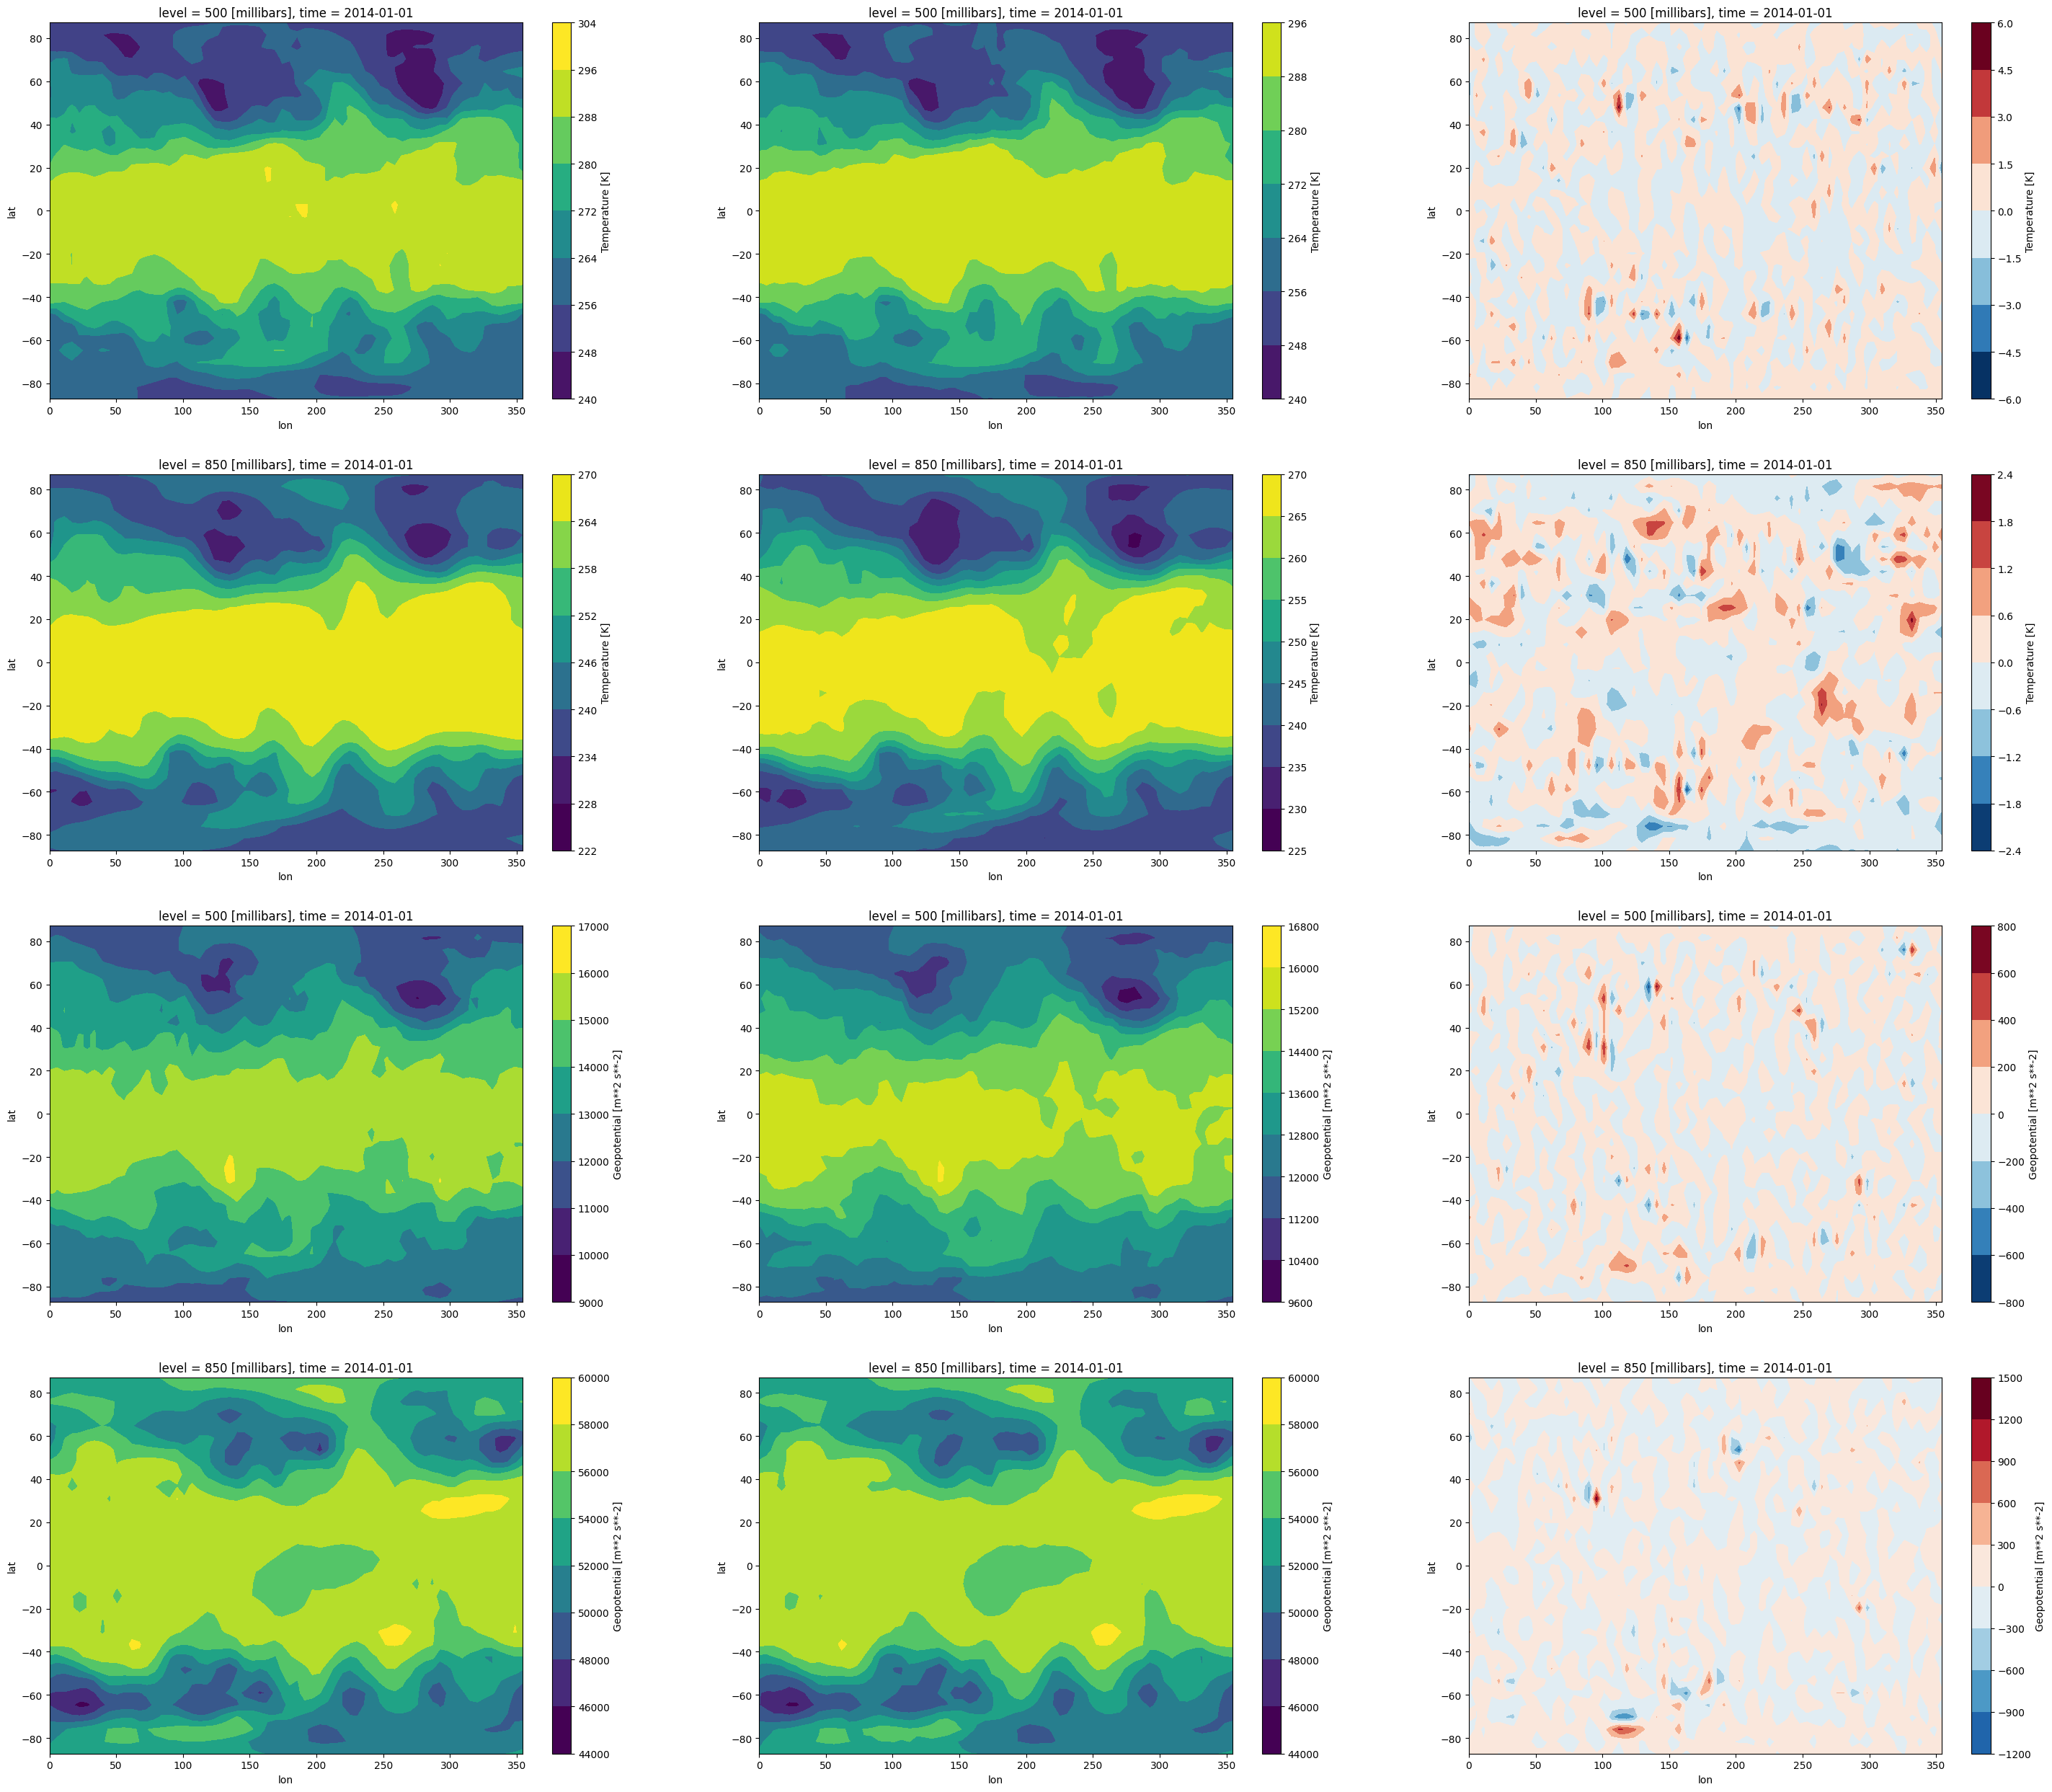

In [119]:
fig1 = matplotlib.pyplot.figure(figsize=(36,80))
ix1 = 0
for v1 in var_subset:
    for p1 in pl_subset:
        ax1 = fig1.add_subplot(10,3,ix1*3+1)
        current_input = sample_input[v1].sel(level=p1)
        current_input.plot.contourf(ax=ax1)
        ax1 = fig1.add_subplot(10,3,ix1*3+2)
        current_pred = sample_pred[v1].sel(level=p1)
        current_pred.plot.contourf(ax=ax1)
        ax1 = fig1.add_subplot(10,3,ix1*3+3)
        (current_input-current_pred).plot.contourf(ax=ax1)
        ix1 +=1
    

### Evaluate the results
Now we want to compare our samples to the predictor. We will start looking at RMSE, using the scores package for evaluation. 

The steps are as follows:
- Loop through batches in the validation data set
- For each batch
  - Make a prediction
  - Denormalise the input and prediction
  - Use scores to calculate RMSE
  - Add to cumulative total
  - Normalise for the number of samples

In [120]:
import scores

In [121]:
len(wb_val_loader)

1096

In [122]:
wb_val_ds._ds_norm.dims

FrozenMappingWarningOnValuesAccess({'time': 17521, 'level': 2, 'lat': 32, 'lon': 64})

In [123]:
metric_dict = { (v1,p1):0.0 for v1 in var_subset for p1 in pl_subset}

In [124]:
num_batches_val = len(wb_val_loader)

In [125]:
%%time
scores_total = None
for batch_ix_val, X_batch_val in enumerate(wb_val_loader):
    rmse_batch = scores.continuous.rmse(
        denormalise_tensor(X_batch_val, std_vec, mean_vec, da_skeletons)[1],
        denormalise_tensor(ae_model.forward(X_batch_val), std_vec, mean_vec, da_skeletons)[1],
        preserve_dims='level',
    )
    if scores_total is None:
        scores_total = rmse_batch
    else:
        scores_total += rmse_batch
            
scores_total /= num_batches_val 

CPU times: user 17min 20s, sys: 1min 27s, total: 18min 48s
Wall time: 14min 50s


In [133]:
scores_df = scores_total.to_dataframe()

<Axes: title={'center': 'RMSE geopotential (K)'}, xlabel='level'>

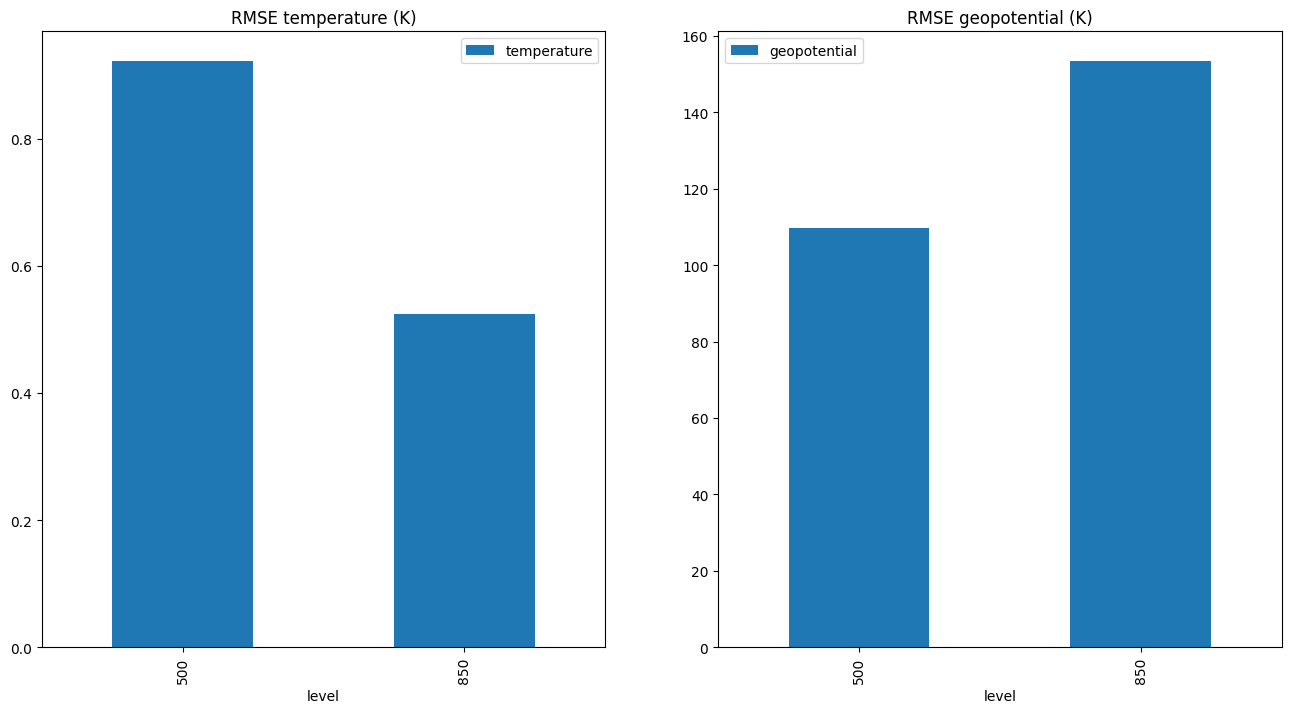

In [142]:
fig1 = matplotlib.pyplot.figure(figsize=(16,8))
ax1 = fig1.add_subplot(1,2,1,title='RMSE temperature (K)')
scores_df.plot.bar(y='temperature', ax=ax1)
ax1 = fig1.add_subplot(1,2,2,title='RMSE geopotential (K)')
scores_df.plot.bar(y='geopotential',ax=ax1)

## Exercises
* Try to explore spatial patterns in the errors
* Look at errors for different seasons, or times of day


### Further Reading
* [Scores evaluation libray](https://scores.readthedocs.io/en/stable/)